In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2

In [2]:
image_path = "data/apple.jpg"
image = mpimg.imread(image_path)

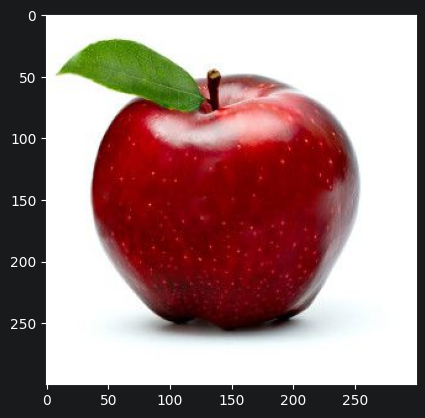

In [3]:
plt.imshow(image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-181.0..358.9285888671875].


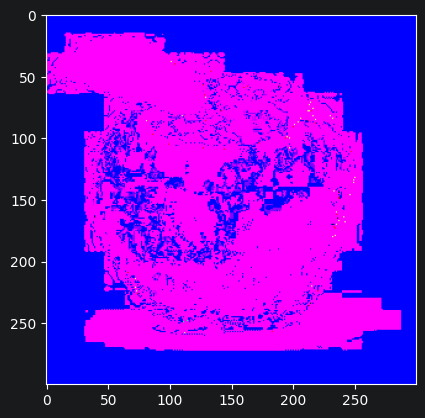

In [5]:
from implementations.color_scheme_convert_functions import  RGB_to_HSL

hsv_image = RGB_to_HSL(image)

plt.imshow(hsv_image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-181.0..358.9285888671875].


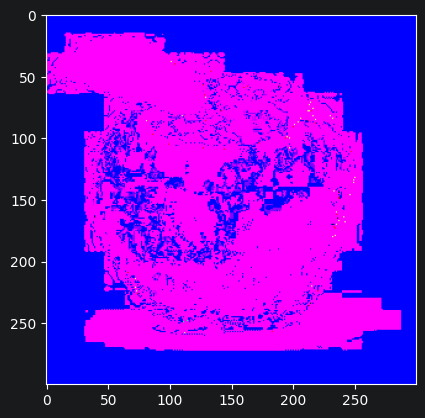

In [6]:
hsl_image = cv2.cvtColor(image, cv2.COLOR_RGB2HLS)
plt.imshow(hsv_image)

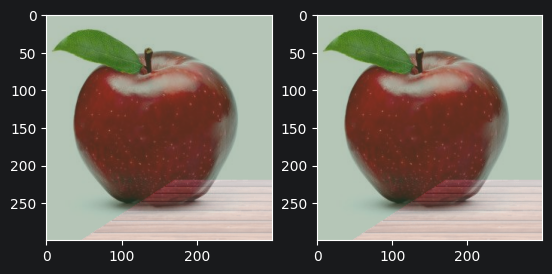

In [7]:
from implementations.blending import blend_image

img1 = cv2.imread('data/apple.jpg')
img2 = cv2.imread('data/table.png')[:img1.shape[0], :img1.shape[1], :3]

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

alpha, beta, gamma = 0.6, 0.4, 0

# my implementation
blended_image = blend_image(img1_rgb.copy(), img2_rgb.copy(), alpha, beta, gamma)

# OpenCV implementation
blended_image_cv = cv2.addWeighted(img1_rgb.copy(), alpha, img2_rgb.copy(), beta, gamma)

# Display both images
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(blended_image)
ax2.imshow(blended_image_cv)

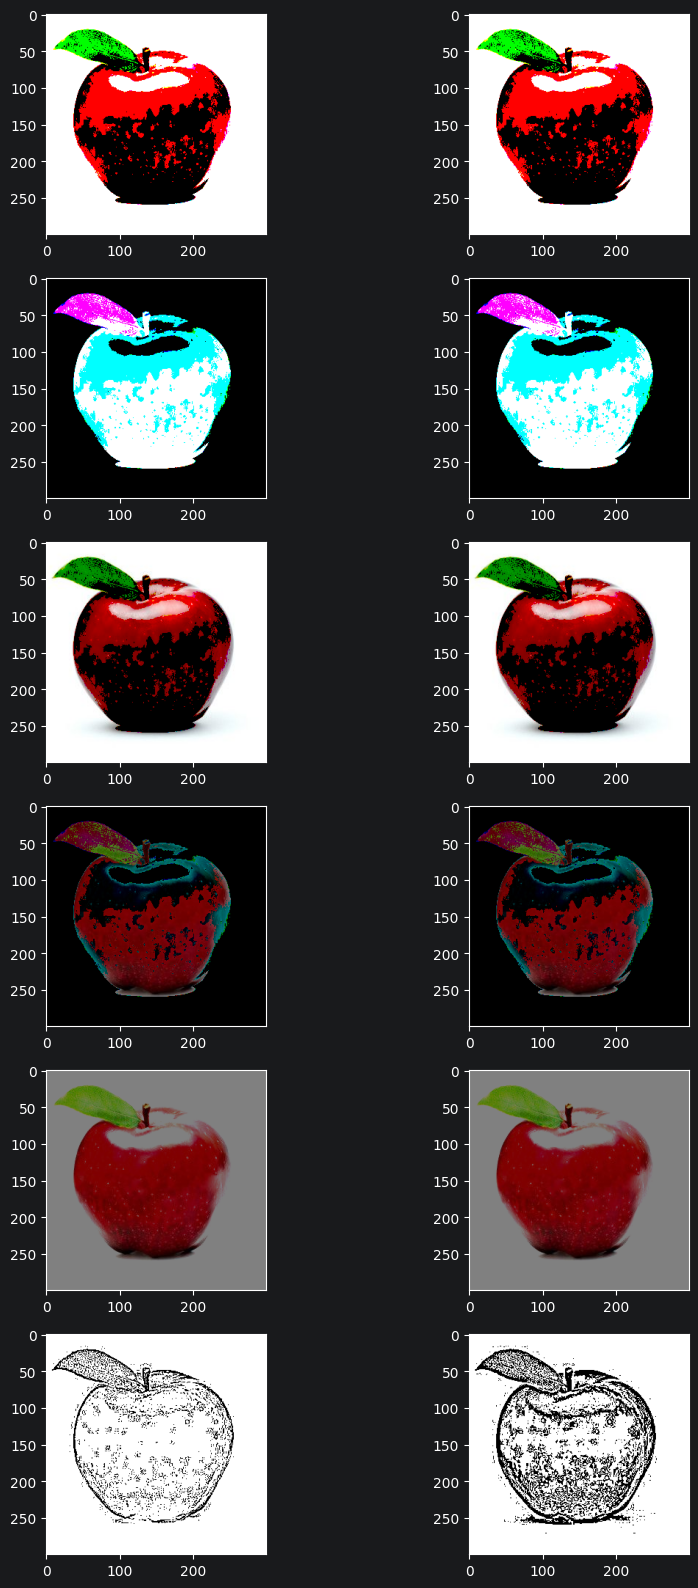

In [9]:
from implementations.threshold_processing import *

image = img1_rgb.copy()

# my implementation
binary_image = binary_thresholding(image, 128)
binary_image_inv = binary_thresholding_inv(image, 128)
tozero_image = to_zero_thresholding(image, 128)
tozero_image_inv = to_zero_thresholding_inv(image, 128)
trunc_thresholding_image = trunc_thresholding(image, 128)
gaussian_thresholding_image = gaussian_thresholding(image[:,:,0], 5, 5)

# openCV implementation
_, binary_image_cv = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
_, binary_image_cv_inv = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV)
_, to_zero_image_cv = cv2.threshold(image, 128, 255, cv2.THRESH_TOZERO)
_, to_zero_image_cv_inv = cv2.threshold(image, 128, 255, cv2.THRESH_TOZERO_INV)
_, trunc_thresholding_image_cv = cv2.threshold(image, 128, 255, cv2.THRESH_TRUNC)
gaussian_thresholding_image_cv = cv2.adaptiveThreshold(cv2.cvtColor(image.copy(), cv2.COLOR_RGB2GRAY), 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,11,2)

# Display both images
fig, axes = plt.subplots(6, 2, figsize=(10, 20))

ax1 = axes[0]
ax1[0].imshow(binary_image, cmap='gray')
ax1[1].imshow(binary_image_cv, cmap='gray')

ax2 = axes[1]
ax2[0].imshow(binary_image_inv, cmap='gray')
ax2[1].imshow(binary_image_cv_inv, cmap='gray')

ax3 = axes[2]
ax3[0].imshow(tozero_image, cmap='gray')
ax3[1].imshow(to_zero_image_cv, cmap='gray')

ax4 = axes[3]
ax4[0].imshow(tozero_image_inv, cmap='gray')
ax4[1].imshow(to_zero_image_cv_inv, cmap='gray')

ax5 = axes[4]
ax5[0].imshow(trunc_thresholding_image, cmap='gray')
ax5[1].imshow(trunc_thresholding_image_cv, cmap='gray')

ax6= axes[5]
ax6[0].imshow(gaussian_thresholding_image, cmap='gray')
ax6[1].imshow(gaussian_thresholding_image_cv, cmap='gray')

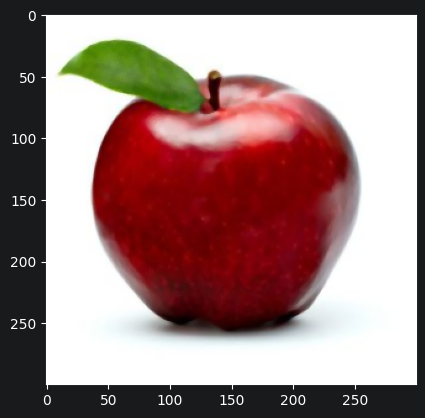

In [10]:
from implementations.blur import median_blur, gaussian_blur

image = img1_rgb.copy()
median_blured = median_blur(image)

plt.imshow(median_blured)

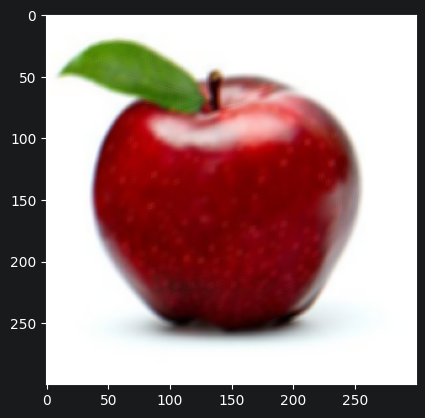

In [11]:
image = img1_rgb.copy()
gaussian_blured = gaussian_blur(image)

plt.imshow(gaussian_blured)

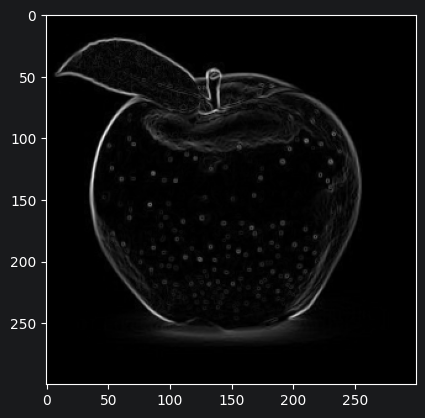

In [12]:
from implementations.sobel_filter import apply_sobel_op

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
sobel_image = apply_sobel_op(image=gray)
plt.imshow(sobel_image, cmap='gray')

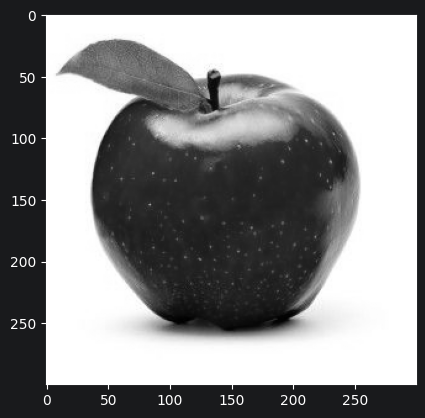

In [13]:
gray_vec = gray.ravel()
freq = np.bincount(gray_vec, minlength=256)
plt.imshow(gray, cmap='gray')

In [14]:
pdf = freq/gray_vec.size
cdf = np.cumsum(pdf)

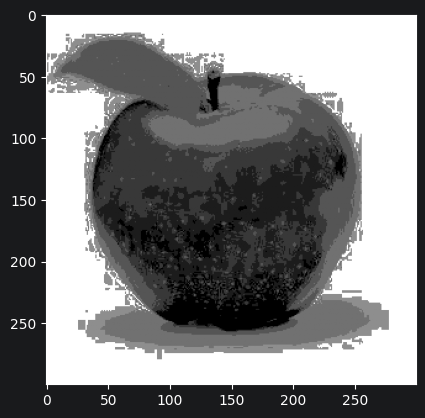

In [15]:
L = 10
transform = np.round((L - 1) * cdf).astype(np.uint8)
equalized = transform[gray]

plt.imshow(equalized, cmap='gray')